In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

In [2]:
shots=4096


noise_circuit = QuantumCircuit(1,1)


noise_circuit.h(0)

noise_circuit.measure(0,0)


print(noise_circuit.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


In [3]:
ideal_backend = AerSimulator()


ideal_result = ideal_backend.run(
    noise_circuit,
    shots=shots
).result()


ideal_counts = ideal_result.get_counts()


print(ideal_counts)

{'0': 2049, '1': 2047}


In [4]:
error = depolarizing_error(
    0.03,
    1
)


noise = NoiseModel()


noise.add_all_qubit_quantum_error(
    error,
    ['h']
)


noisy_backend = AerSimulator(
    noise_model=noise
)


noisy_result=noisy_backend.run(
    noise_circuit,
    shots=shots
).result()


noisy_counts=noisy_result.get_counts()


print(noisy_counts)

{'1': 2076, '0': 2020}


In [5]:
states=["0","1"]


ideal_probability=[]

noise_probability=[]


for state in states:

    ideal_probability.append(
        ideal_counts.get(state,0)/shots
    )


    noise_probability.append(
        noisy_counts.get(state,0)/shots
    )

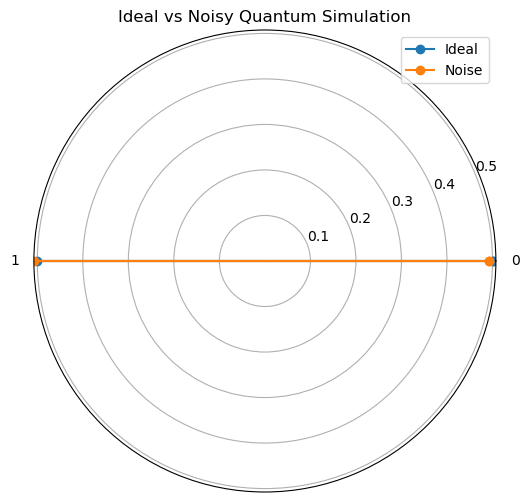

In [6]:
import numpy as np


angles=np.linspace(
    0,
    2*np.pi,
    len(states),
    endpoint=False
)


angles=np.concatenate(
    (angles,[angles[0]])
)


ideal_plot=ideal_probability+[ideal_probability[0]]

noise_plot=noise_probability+[noise_probability[0]]


plt.figure(figsize=(6,6))


ax=plt.subplot(111,polar=True)


ax.plot(
    angles,
    ideal_plot,
    marker='o',
    label="Ideal"
)


ax.plot(
    angles,
    noise_plot,
    marker='o',
    label="Noise"
)


ax.set_xticks(angles[:-1])

ax.set_xticklabels(states)


plt.title("Ideal vs Noisy Quantum Simulation")

plt.legend()


plt.show()

In [7]:
print("Observation:")

print("Ideal simulator gives perfect quantum behaviour.")

print("Noise simulator introduces small errors similar to real quantum devices.")

Observation:
Ideal simulator gives perfect quantum behaviour.
Noise simulator introduces small errors similar to real quantum devices.
